In [ ]:
# ==========================================
# INSTALL
# ==========================================
!pip install -q sentence-transformers evaluate sacrebleu rouge-score matplotlib tqdm scikit-learn

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 6.4 MB/s eta 0:00:00


In [ ]:
# ==========================================
# IMPORTS
# ==========================================
import os
import gc
import json
import torch
import evaluate
import sacrebleu
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm
from sentence_transformers import SentenceTransformer

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ==========================================
# OUTPUT BASE
# ==========================================
BASE_DIR = "/content/drive/MyDrive/MALAYALAM_EVALUATION"

os.makedirs(BASE_DIR, exist_ok=True)

In [ ]:
# ==========================================
# EMBEDDING MODEL
# ==========================================
gc.collect()
torch.cuda.empty_cache()

embedding_model = SentenceTransformer(
    "intfloat/multilingual-e5-base",
    device="cpu"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/418 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]

In [ ]:
# ==========================================
# UNIVERSAL CSV LOADER
# ==========================================
def load_prediction_csv(csv_path):
    df = pd.read_csv(csv_path)
    df = df.fillna("")

    cols = df.columns.tolist()

    if "Article" in cols:
        df = df.rename(columns={
            "Article": "article",
            "Reference": "reference",
            "Prediction": "prediction"
        })

    required = ["article", "reference", "prediction"]

    for col in required:
        if col not in df.columns:
            raise ValueError(f"Missing column: {col}")

    df["article"] = df["article"].astype(str)
    df["reference"] = df["reference"].astype(str)
    df["prediction"] = df["prediction"].astype(str)

    return df

In [ ]:
# ==========================================
# EVALUATION FUNCTION
# ==========================================
def evaluate_model(csv_path, model_name, setting):

    print(f"Evaluating {model_name} ({setting})")

    save_dir = f"{BASE_DIR}/{model_name}_{setting}"
    os.makedirs(save_dir, exist_ok=True)

    df = load_prediction_csv(csv_path)

    articles = df["article"].tolist()
    references = df["reference"].tolist()
    predictions = df["prediction"].tolist()

    # -----------------------------
    # ROUGE + BLEU
    # -----------------------------
    rouge = evaluate.load("rouge")

    rouge_scores = rouge.compute(
        predictions=predictions,
        references=references
    )

    bleu = sacrebleu.corpus_bleu(
        predictions,
        [references]
    ).score

    # -----------------------------
    # BERTScore approximation
    # -----------------------------
    pred_emb = embedding_model.encode(
        predictions,
        batch_size=16,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True
    )

    ref_emb = embedding_model.encode(
        references,
        batch_size=16,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True
    )

    bert_per_sample = np.sum(pred_emb * ref_emb, axis=1)
    bertscore = bert_per_sample.mean()

    # -----------------------------
    # Article as context
    # -----------------------------
    article_emb = embedding_model.encode(
        articles,
        batch_size=16,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True
    )

    # -----------------------------
    # Faithfulness
    # -----------------------------
    faithfulness_scores = np.sum(pred_emb * article_emb, axis=1)
    faithfulness = faithfulness_scores.mean()

    # -----------------------------
    # Context Precision
    # -----------------------------
    cp_scores = []

    for pred, article in tqdm(zip(predictions, articles), total=len(predictions)):
        pred_sentences = pred.split(".")

        if len(pred_sentences) == 0:
            cp_scores.append(0)
            continue

        article_emb_local = embedding_model.encode(
            article,
            convert_to_numpy=True,
            normalize_embeddings=True
        )

        supported = 0
        valid_sent = 0

        for sent in pred_sentences:
            sent = sent.strip()

            if len(sent) < 5:
                continue

            valid_sent += 1

            sent_emb = embedding_model.encode(
                sent,
                convert_to_numpy=True,
                normalize_embeddings=True
            )

            sim = np.dot(sent_emb, article_emb_local)

            if sim > 0.65:
                supported += 1

        cp = supported / max(valid_sent, 1)
        cp_scores.append(cp)

    cp_scores = np.array(cp_scores)
    context_precision = cp_scores.mean()

    # -----------------------------
    # Context Recall
    # -----------------------------
    cr_scores = []

    for pred, article in tqdm(zip(predictions, articles), total=len(predictions)):
        article_chunks = [
            c for c in article.split(".")
            if len(c.strip()) > 20
        ]

        pred_emb_local = embedding_model.encode(
            pred,
            convert_to_numpy=True,
            normalize_embeddings=True
        )

        covered = 0

        for chunk in article_chunks:
            chunk_emb = embedding_model.encode(
                chunk,
                convert_to_numpy=True,
                normalize_embeddings=True
            )

            sim = np.dot(pred_emb_local, chunk_emb)

            if sim > 0.65:
                covered += 1

        cr = covered / max(len(article_chunks), 1)
        cr_scores.append(cr)

    cr_scores = np.array(cr_scores)
    context_recall = cr_scores.mean()

    # -----------------------------
    # Hallucination
    # -----------------------------
    hallucination_scores = 1 - (
        0.4 * faithfulness_scores +
        0.2 * cp_scores +
        0.2 * cr_scores +
        0.2 * bert_per_sample
    )

    hallucination_rate = (hallucination_scores > 0.5).mean()

    # -----------------------------
    # Summary
    # -----------------------------
    summary_metrics = {
        "Model": model_name,
        "Setting": setting,

        "ROUGE1": float(rouge_scores["rouge1"]),
        "ROUGE2": float(rouge_scores["rouge2"]),
        "ROUGEL": float(rouge_scores["rougeL"]),
        "BLEU": float(bleu),
        "BERTScore": float(bertscore),

        "Faithfulness": float(faithfulness),
        "ContextPrecision": float(context_precision),
        "ContextRecall": float(context_recall),

        "HallucinationScore": float(hallucination_scores.mean()),
        "HallucinationRate": float(hallucination_rate)
    }

    # -----------------------------
    # Save full results
    # -----------------------------
    full_df = pd.DataFrame({
        "article": articles,
        "reference": references,
        "prediction": predictions,
        "bertscore": bert_per_sample,
        "faithfulness": faithfulness_scores,
        "context_precision": cp_scores,
        "context_recall": cr_scores,
        "hallucination_score": hallucination_scores
    })

    full_df.to_csv(f"{save_dir}/full_results.csv", index=False)

    # -----------------------------
    # Save JSON
    # -----------------------------
    with open(f"{save_dir}/summary_metrics.json", "w") as f:
        json.dump(summary_metrics, f, indent=4)

    # -----------------------------
    # Quality plot
    # -----------------------------
    plt.figure(figsize=(10,6))

    q_names = ["ROUGE1","ROUGE2","ROUGEL","BLEU","BERT"]
    q_vals = [
        summary_metrics["ROUGE1"],
        summary_metrics["ROUGE2"],
        summary_metrics["ROUGEL"],
        summary_metrics["BLEU"]/100,
        summary_metrics["BERTScore"]
    ]

    plt.bar(q_names, q_vals)
    plt.title(f"{model_name} {setting} Quality")
    plt.tight_layout()
    plt.savefig(f"{save_dir}/quality_metrics.png")
    plt.close()

    # -----------------------------
    # Hallucination plot
    # -----------------------------
    plt.figure(figsize=(10,6))

    h_names = ["Faithfulness","CP","CR","HS","HR"]
    h_vals = [
        summary_metrics["Faithfulness"],
        summary_metrics["ContextPrecision"],
        summary_metrics["ContextRecall"],
        summary_metrics["HallucinationScore"],
        summary_metrics["HallucinationRate"]
    ]

    plt.bar(h_names, h_vals)
    plt.title(f"{model_name} {setting} Hallucination")
    plt.tight_layout()
    plt.savefig(f"{save_dir}/hallucination_metrics.png")
    plt.close()

    # -----------------------------
    # Distribution
    # -----------------------------
    plt.figure(figsize=(10,6))
    plt.hist(hallucination_scores, bins=30)
    plt.title(f"{model_name} {setting} HS Distribution")
    plt.tight_layout()
    plt.savefig(f"{save_dir}/hallucination_distribution.png")
    plt.close()

    gc.collect()
    torch.cuda.empty_cache()

    return summary_metrics

In [ ]:
# ==========================================
# TWO-SHOT FILE PATHS
# ==========================================
PRED_DIR = "/content/drive/MyDrive/MALAYALAM_EVALUATION"

two_shot_models = [
    (
        f"{PRED_DIR}/sarvam_predictions_twoshot.csv",
        "Sarvam",
        "TwoShot"
    ),
    (
        f"{PRED_DIR}/bloomz_predictions_twoshot.csv",
        "BLOOMZ",
        "TwoShot"
    ),
    (
        f"{PRED_DIR}/mt5_predictions_twoshot.csv",
        "mT5",
        "TwoShot"
    ),
    (
        f"{PRED_DIR}/mbart_predictions_twoshot.csv",
        "mBART",
        "TwoShot"
    )
]

In [ ]:
# ==========================================
# RUN TWO-SHOT
# ==========================================
two_shot_results = []

for csv_path, model_name, setting in two_shot_models:
    result = evaluate_model(
        csv_path=csv_path,
        model_name=model_name,
        setting=setting
    )

    two_shot_results.append(result)

Evaluating Sarvam (TwoShot)


Batches:   0%|          | 0/63 [00:00<?, ?it/s]

Batches:   0%|          | 0/63 [00:00<?, ?it/s]

Batches:   0%|          | 0/63 [00:00<?, ?it/s]

100%|██████████| 1000/1000 [08:49<00:00,  1.89it/s]


...

Evaluating mBART (TwoShot)


Batches:   0%|          | 0/61 [00:00<?, ?it/s]

Batches:   0%|          | 0/61 [00:00<?, ?it/s]

Batches:   0%|          | 0/61 [00:00<?, ?it/s]

100%|██████████| 970/970 [07:14<00:00,  2.23it/s]


In [ ]:
# ==========================================
# TWO-SHOT SUMMARY
# ==========================================
two_df = pd.DataFrame(two_shot_results)

display(two_df)

,Model,Setting,ROUGE1,ROUGE2,ROUGEL,BLEU,BERTScore,Faithfulness,ContextPrecision,ContextRecall,HallucinationScore,HallucinationRate
0,Sarvam,TwoShot,0.000471,0.000000,0.000451,0.342049,0.816985,0.838780,1.000000,1.0,0.101091,0.0
1,BLOOMZ,TwoShot,0.009966,0.000000,0.009966,0.024048,0.773784,0.772429,0.991753,1.0,0.137921,0.0
2,mT5,TwoShot,0.004400,0.000395,0.004380,0.957940,0.834877,0.874746,1.000000,1.0,0.083126,0.0
3,mBART,TwoShot,0.006529,0.000000,0.006186,1.524800,0.802297,0.818707,0.824742,1.0,0.147110,0.0


In [ ]:
two_df.to_csv(
    "/content/drive/MyDrive/MALAYALAM_EVALUATION/two_shot_summary.csv",
    index=False
)

print("saved")

saved


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

BASE_DIR = "/content/drive/MyDrive/MALAYALAM_EVALUATION"

zero_df = pd.read_csv(f"{BASE_DIR}/zero_shot_summary.csv")
two_df = pd.read_csv(f"{BASE_DIR}/two_shot_summary.csv")

comparison_df = pd.concat([zero_df, two_df], ignore_index=True)

display(comparison_df)

,Model,Setting,ROUGE1,ROUGE2,ROUGEL,BLEU,BERTScore,Faithfulness,ContextPrecision,ContextRecall,HallucinationScore,HallucinationRate
0,Sarvam,ZeroShot,0.002168,0.000142,0.002208,0.802404,0.816132,0.854938,0.967010,1.0,0.101397,0.0
1,BLOOMZ,ZeroShot,0.013747,0.000000,0.013727,1.068298,0.795823,0.811640,0.992784,1.0,0.117623,0.0
2,mT5,ZeroShot,0.000295,0.000000,0.000295,0.025067,0.768236,0.763569,1.000000,1.0,0.140925,0.0
3,mBART,ZeroShot,0.014320,0.001718,0.014489,0.686449,0.809734,0.847780,0.898969,1.0,0.119147,0.0
4,Sarvam,TwoShot,0.000471,0.000000,0.000451,0.342049,0.816985,0.838780,1.000000,1.0,0.101091,0.0
5,BLOOMZ,TwoShot,0.009966,0.000000,0.009966,0.024048,0.773784,0.772429,0.991753,1.0,0.137921,0.0
6,mT5,TwoShot,0.004400,0.000395,0.004380,0.957940,0.834877,0.874746,1.000000,1.0,0.083126,0.0
7,mBART,TwoShot,0.006529,0.000000,0.006186,1.524800,0.802297,0.818707,0.824742,1.0,0.147110,0.0


In [ ]:
comparison_df.to_csv(
    f"{BASE_DIR}/all_model_comparison.csv",
    index=False
)

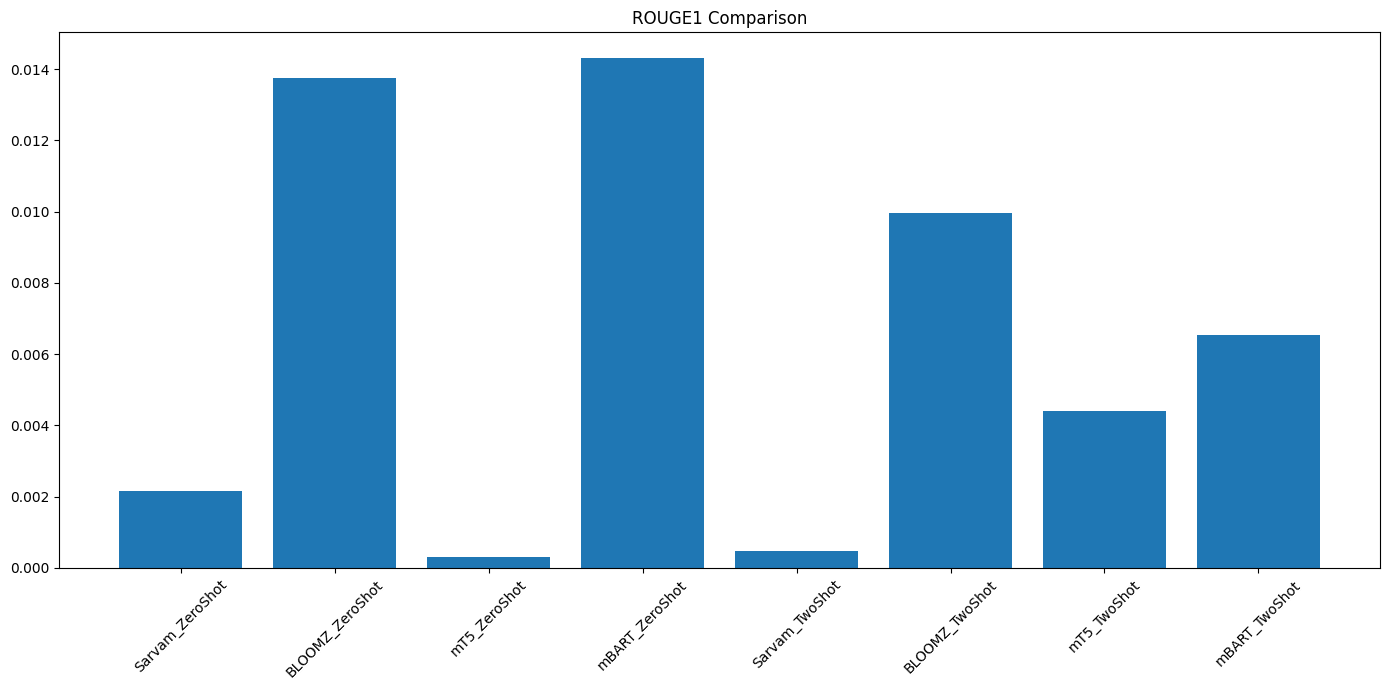

In [ ]:
plt.figure(figsize=(14,7))

labels = comparison_df["Model"] + "_" + comparison_df["Setting"]

plt.bar(labels, comparison_df["ROUGE1"])
plt.xticks(rotation=45)
plt.title("ROUGE1 Comparison")
plt.tight_layout()

plt.savefig(f"{BASE_DIR}/overall_rouge1_comparison.png")
plt.show()

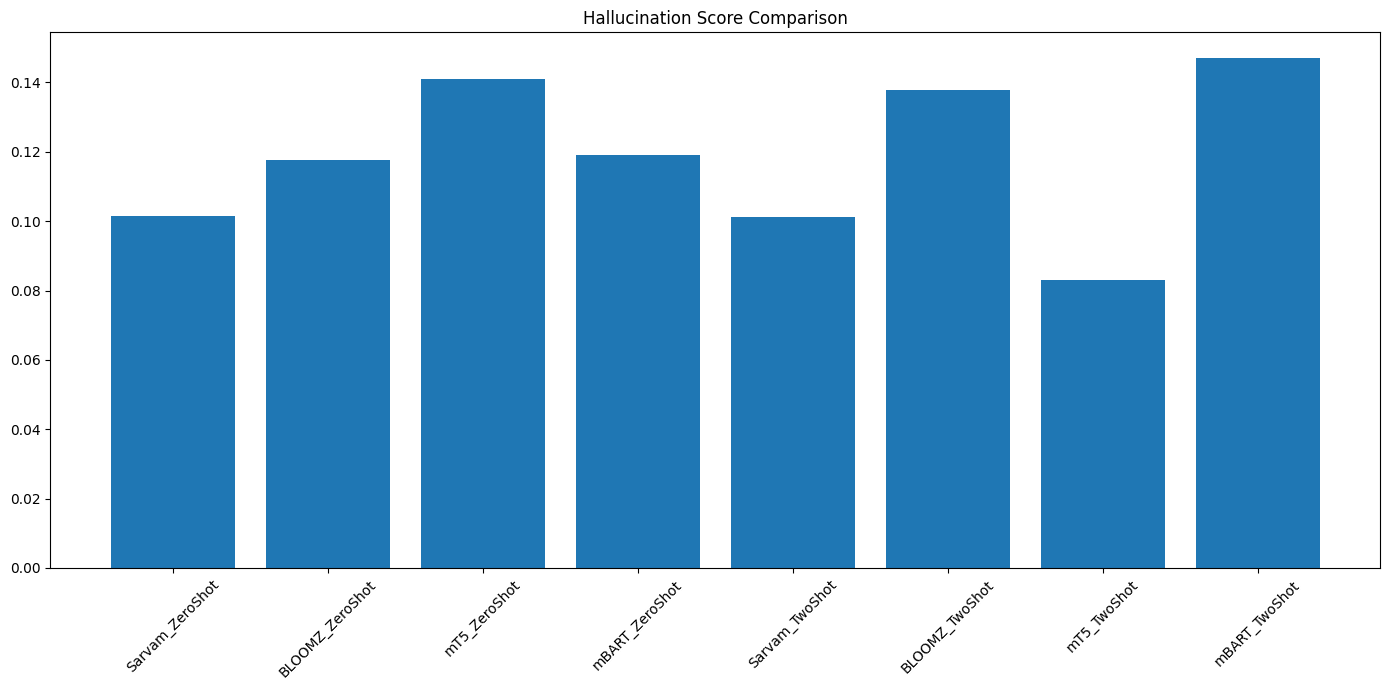

In [ ]:
plt.figure(figsize=(14,7))

plt.bar(labels, comparison_df["HallucinationScore"])
plt.xticks(rotation=45)
plt.title("Hallucination Score Comparison")
plt.tight_layout()

plt.savefig(f"{BASE_DIR}/overall_hallucination_comparison.png")
plt.show()

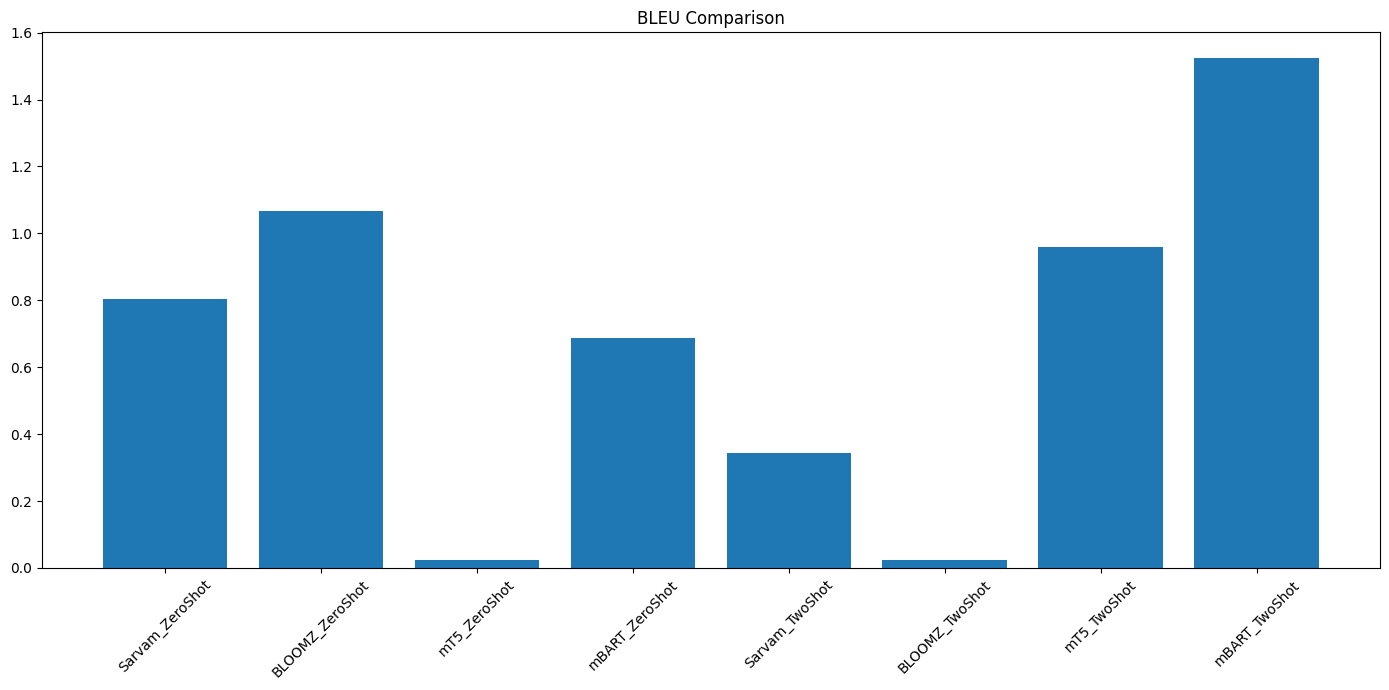

In [ ]:
plt.figure(figsize=(14,7))

labels = comparison_df["Model"] + "_" + comparison_df["Setting"]

plt.bar(labels, comparison_df["BLEU"])
plt.xticks(rotation=45)
plt.title("BLEU Comparison")
plt.tight_layout()

plt.savefig(f"{BASE_DIR}/overall_bleu_comparison.png")
plt.show()

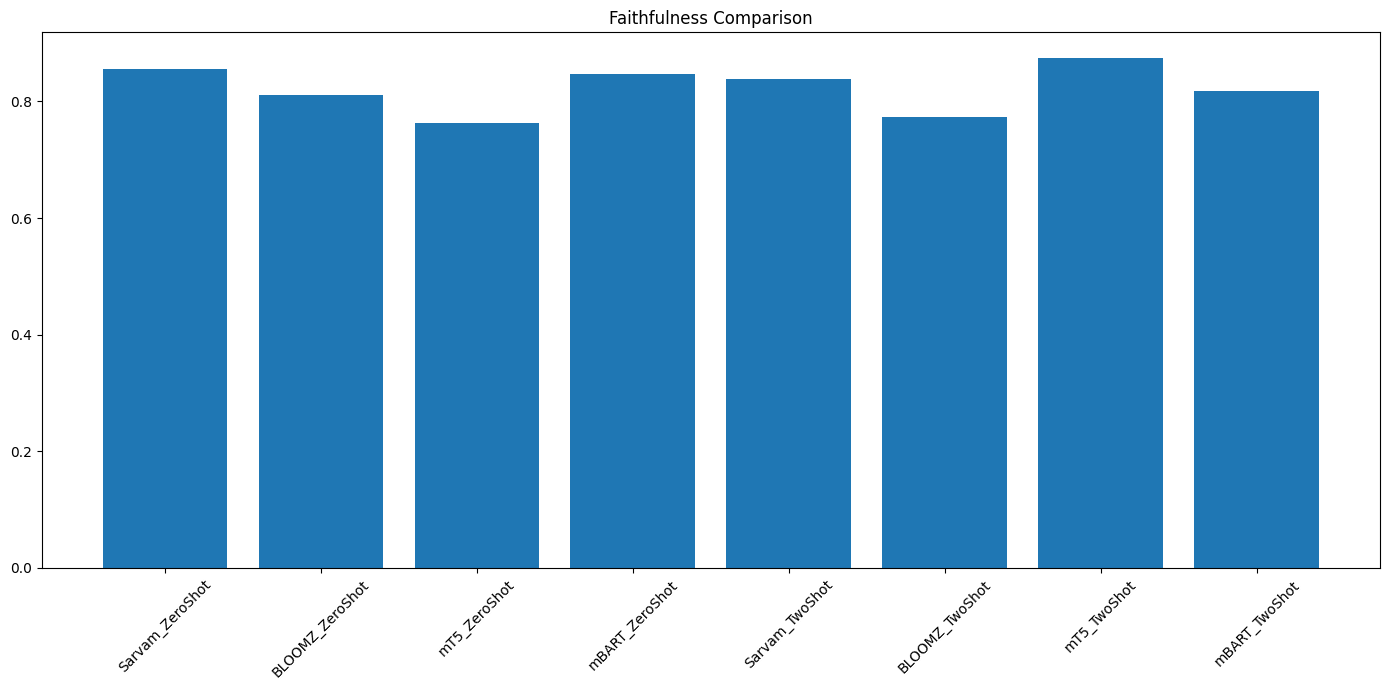

In [ ]:
plt.figure(figsize=(14,7))

plt.bar(labels, comparison_df["Faithfulness"])
plt.xticks(rotation=45)
plt.title("Faithfulness Comparison")
plt.tight_layout()

plt.savefig(f"{BASE_DIR}/overall_faithfulness_comparison.png")
plt.show()

In [ ]:
comparison_df.sort_values(
    by="HallucinationScore",
    ascending=True
)

,Model,Setting,ROUGE1,ROUGE2,ROUGEL,BLEU,BERTScore,Faithfulness,ContextPrecision,ContextRecall,HallucinationScore,HallucinationRate
6,mT5,TwoShot,0.004400,0.000395,0.004380,0.957940,0.834877,0.874746,1.000000,1.0,0.083126,0.0
4,Sarvam,TwoShot,0.000471,0.000000,0.000451,0.342049,0.816985,0.838780,1.000000,1.0,0.101091,0.0
0,Sarvam,ZeroShot,0.002168,0.000142,0.002208,0.802404,0.816132,0.854938,0.967010,1.0,0.101397,0.0
1,BLOOMZ,ZeroShot,0.013747,0.000000,0.013727,1.068298,0.795823,0.811640,0.992784,1.0,0.117623,0.0
3,mBART,ZeroShot,0.014320,0.001718,0.014489,0.686449,0.809734,0.847780,0.898969,1.0,0.119147,0.0
5,BLOOMZ,TwoShot,0.009966,0.000000,0.009966,0.024048,0.773784,0.772429,0.991753,1.0,0.137921,0.0
2,mT5,ZeroShot,0.000295,0.000000,0.000295,0.025067,0.768236,0.763569,1.000000,1.0,0.140925,0.0
7,mBART,TwoShot,0.006529,0.000000,0.006186,1.524800,0.802297,0.818707,0.824742,1.0,0.147110,0.0


In [ ]:
comparison_df.sort_values(
    by="ROUGE1",
    ascending=False
)

,Model,Setting,ROUGE1,ROUGE2,ROUGEL,BLEU,BERTScore,Faithfulness,ContextPrecision,ContextRecall,HallucinationScore,HallucinationRate
3,mBART,ZeroShot,0.014320,0.001718,0.014489,0.686449,0.809734,0.847780,0.898969,1.0,0.119147,0.0
1,BLOOMZ,ZeroShot,0.013747,0.000000,0.013727,1.068298,0.795823,0.811640,0.992784,1.0,0.117623,0.0
5,BLOOMZ,TwoShot,0.009966,0.000000,0.009966,0.024048,0.773784,0.772429,0.991753,1.0,0.137921,0.0
7,mBART,TwoShot,0.006529,0.000000,0.006186,1.524800,0.802297,0.818707,0.824742,1.0,0.147110,0.0
6,mT5,TwoShot,0.004400,0.000395,0.004380,0.957940,0.834877,0.874746,1.000000,1.0,0.083126,0.0
0,Sarvam,ZeroShot,0.002168,0.000142,0.002208,0.802404,0.816132,0.854938,0.967010,1.0,0.101397,0.0
4,Sarvam,TwoShot,0.000471,0.000000,0.000451,0.342049,0.816985,0.838780,1.000000,1.0,0.101091,0.0
2,mT5,ZeroShot,0.000295,0.000000,0.000295,0.025067,0.768236,0.763569,1.000000,1.0,0.140925,0.0


In [ ]:
comparison_df.sort_values(
    by="HallucinationScore"
).to_csv(
    f"{BASE_DIR}/ranked_by_hallucination.csv",
    index=False
)

In [ ]:
# ==========================================
# INSTALL
# ==========================================
!pip install -q sentence-transformers evaluate sacrebleu rouge-score matplotlib tqdm scikit-learn

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 11.9 MB/s eta 0:00:00


In [ ]:
# ==========================================
# IMPORTS
# ==========================================
import os
import gc
import json
import torch
import evaluate
import sacrebleu
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm
from sentence_transformers import SentenceTransformer

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ==========================================
# OUTPUT BASE
# ==========================================
BASE_DIR = "/content/drive/MyDrive/MALAYALAM_FINETUNED_EVALUATION"

os.makedirs(BASE_DIR, exist_ok=True)

In [ ]:
# ==========================================
# EMBEDDING MODEL
# ==========================================
gc.collect()
torch.cuda.empty_cache()

embedding_model = SentenceTransformer(
    "intfloat/multilingual-e5-base",
    device="cpu"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/418 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]

In [ ]:
# ==========================================
# UNIVERSAL CSV LOADER
# ==========================================
def load_prediction_csv(csv_path):
    df = pd.read_csv(csv_path)
    df = df.fillna("")

    cols = df.columns.tolist()

    if "Article" in cols:
        df = df.rename(columns={
            "Article": "article",
            "Reference": "reference",
            "Prediction": "prediction"
        })

    required = ["article", "reference", "prediction"]

    for col in required:
        if col not in df.columns:
            raise ValueError(f"Missing column: {col}")

    df["article"] = df["article"].astype(str)
    df["reference"] = df["reference"].astype(str)
    df["prediction"] = df["prediction"].astype(str)

    return df

In [ ]:
# ==========================================
# UNIVERSAL EVALUATOR
# ==========================================
def evaluate_model(csv_path, model_name, setting):

    print(f"Evaluating {model_name} ({setting})")

    save_dir = f"{BASE_DIR}/{model_name}_{setting}"
    os.makedirs(save_dir, exist_ok=True)

    df = load_prediction_csv(csv_path)

    articles = df["article"].tolist()
    references = df["reference"].tolist()
    predictions = df["prediction"].tolist()

    # -----------------------------------
    # ROUGE
    # -----------------------------------
    rouge = evaluate.load("rouge")

    rouge_scores = rouge.compute(
        predictions=predictions,
        references=references
    )

    # -----------------------------------
    # BLEU
    # -----------------------------------
    bleu = sacrebleu.corpus_bleu(
        predictions,
        [references]
    ).score

    # -----------------------------------
    # EMBEDDINGS
    # -----------------------------------
    pred_emb = embedding_model.encode(
        predictions,
        batch_size=16,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True
    )

    ref_emb = embedding_model.encode(
        references,
        batch_size=16,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True
    )

    article_emb = embedding_model.encode(
        articles,
        batch_size=16,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True
    )

    # -----------------------------------
    # BERTScore approximation
    # -----------------------------------
    bert_per_sample = np.sum(pred_emb * ref_emb, axis=1)
    bertscore = bert_per_sample.mean()

    # -----------------------------------
    # Faithfulness
    # -----------------------------------
    faithfulness_scores = np.sum(pred_emb * article_emb, axis=1)
    faithfulness = faithfulness_scores.mean()

    # -----------------------------------
    # Context Precision
    # -----------------------------------
    cp_scores = []

    for pred, article in tqdm(zip(predictions, articles), total=len(predictions)):

        pred_sentences = pred.split(".")

        if len(pred_sentences) == 0:
            cp_scores.append(0)
            continue

        article_emb_local = embedding_model.encode(
            article,
            convert_to_numpy=True,
            normalize_embeddings=True
        )

        supported = 0
        valid_sent = 0

        for sent in pred_sentences:
            sent = sent.strip()

            if len(sent) < 5:
                continue

            valid_sent += 1

            sent_emb = embedding_model.encode(
                sent,
                convert_to_numpy=True,
                normalize_embeddings=True
            )

            sim = np.dot(sent_emb, article_emb_local)

            if sim > 0.65:
                supported += 1

        cp = supported / max(valid_sent, 1)
        cp_scores.append(cp)

    cp_scores = np.array(cp_scores)
    context_precision = cp_scores.mean()

    # -----------------------------------
    # Context Recall
    # -----------------------------------
    cr_scores = []

    for pred, article in tqdm(zip(predictions, articles), total=len(predictions)):

        article_chunks = [
            c for c in article.split(".")
            if len(c.strip()) > 20
        ]

        pred_emb_local = embedding_model.encode(
            pred,
            convert_to_numpy=True,
            normalize_embeddings=True
        )

        covered = 0

        for chunk in article_chunks:

            chunk_emb = embedding_model.encode(
                chunk,
                convert_to_numpy=True,
                normalize_embeddings=True
            )

            sim = np.dot(pred_emb_local, chunk_emb)

            if sim > 0.65:
                covered += 1

        cr = covered / max(len(article_chunks), 1)
        cr_scores.append(cr)

    cr_scores = np.array(cr_scores)
    context_recall = cr_scores.mean()

    # -----------------------------------
    # Hallucination Score
    # -----------------------------------
    hallucination_scores = 1 - (
        0.4 * faithfulness_scores +
        0.2 * cp_scores +
        0.2 * cr_scores +
        0.2 * bert_per_sample
    )

    hallucination_rate = (hallucination_scores > 0.5).mean()

    # -----------------------------------
    # SUMMARY
    # -----------------------------------
    summary_metrics = {
        "Model": model_name,
        "Setting": setting,

        "ROUGE1": float(rouge_scores["rouge1"]),
        "ROUGE2": float(rouge_scores["rouge2"]),
        "ROUGEL": float(rouge_scores["rougeL"]),
        "BLEU": float(bleu),
        "BERTScore": float(bertscore),

        "Faithfulness": float(faithfulness),
        "ContextPrecision": float(context_precision),
        "ContextRecall": float(context_recall),

        "HallucinationScore": float(hallucination_scores.mean()),
        "HallucinationRate": float(hallucination_rate)
    }

    # -----------------------------------
    # FULL RESULTS
    # -----------------------------------
    full_df = pd.DataFrame({
        "article": articles,
        "reference": references,
        "prediction": predictions,
        "bertscore": bert_per_sample,
        "faithfulness": faithfulness_scores,
        "context_precision": cp_scores,
        "context_recall": cr_scores,
        "hallucination_score": hallucination_scores
    })

    full_df.to_csv(f"{save_dir}/full_results.csv", index=False)

    # -----------------------------------
    # JSON
    # -----------------------------------
    with open(f"{save_dir}/summary_metrics.json", "w") as f:
        json.dump(summary_metrics, f, indent=4)

    # -----------------------------------
    # QUALITY PLOT
    # -----------------------------------
    plt.figure(figsize=(10,6))

    q_names = ["ROUGE1","ROUGE2","ROUGEL","BLEU","BERT"]
    q_vals = [
        summary_metrics["ROUGE1"],
        summary_metrics["ROUGE2"],
        summary_metrics["ROUGEL"],
        summary_metrics["BLEU"]/100,
        summary_metrics["BERTScore"]
    ]

    plt.bar(q_names, q_vals)
    plt.title(f"{model_name} {setting} Quality")
    plt.tight_layout()
    plt.savefig(f"{save_dir}/quality_metrics.png")
    plt.close()

    # -----------------------------------
    # HALLUCINATION PLOT
    # -----------------------------------
    plt.figure(figsize=(10,6))

    h_names = ["Faithfulness","CP","CR","HS","HR"]
    h_vals = [
        summary_metrics["Faithfulness"],
        summary_metrics["ContextPrecision"],
        summary_metrics["ContextRecall"],
        summary_metrics["HallucinationScore"],
        summary_metrics["HallucinationRate"]
    ]

    plt.bar(h_names, h_vals)
    plt.title(f"{model_name} {setting} Hallucination")
    plt.tight_layout()
    plt.savefig(f"{save_dir}/hallucination_metrics.png")
    plt.close()

    # -----------------------------------
    # DISTRIBUTION
    # -----------------------------------
    plt.figure(figsize=(10,6))
    plt.hist(hallucination_scores, bins=30)
    plt.title(f"{model_name} {setting} HS Distribution")
    plt.tight_layout()
    plt.savefig(f"{save_dir}/hallucination_distribution.png")
    plt.close()

    gc.collect()
    torch.cuda.empty_cache()

    return summary_metrics

In [ ]:
# ==========================================
# CORRECT FILE PATHS
# ==========================================
PRED_DIR = "/content/drive/MyDrive/MALAYALAM_FINETUNED_EVALUATION"

finetuned_models = [
    (
        f"{PRED_DIR}/mbart_predictions_finetuned.csv",
        "mBART",
        "FineTuned"
    ),
    (
        f"{PRED_DIR}/mt5_predictions_finetuned.csv",
        "mT5",
        "FineTuned"
    ),
    (
        f"{PRED_DIR}/bloomz_predictions_finetuned.csv",
        "BLOOMZ",
        "FineTuned"
    ),
    (
        f"{PRED_DIR}/sarvam_predictions_finetuned.csv",
        "Sarvam",
        "FineTuned"
    )
]

In [ ]:
# ==========================================
# RUN FINETUNED EVALUATION
# ==========================================
finetuned_results = []

for csv_path, model_name, setting in finetuned_models:
    result = evaluate_model(
        csv_path=csv_path,
        model_name=model_name,
        setting=setting
    )

    finetuned_results.append(result)

Evaluating mBART (FineTuned)


Batches:   0%|          | 0/61 [00:00<?, ?it/s]

Batches:   0%|          | 0/61 [00:00<?, ?it/s]

Batches:   0%|          | 0/61 [00:00<?, ?it/s]

100%|██████████| 970/970 [06:27<00:00,  2.51it/s]


...

Evaluating Sarvam (FineTuned)


Batches:   0%|          | 0/61 [00:00<?, ?it/s]

Batches:   0%|          | 0/61 [00:00<?, ?it/s]

Batches:   0%|          | 0/61 [00:00<?, ?it/s]

100%|██████████| 970/970 [06:41<00:00,  2.42it/s]


In [ ]:
# ==========================================
# SUMMARY TABLE
# ==========================================
finetuned_df = pd.DataFrame(finetuned_results)

display(finetuned_df)

,Model,Setting,ROUGE1,ROUGE2,ROUGEL,BLEU,BERTScore,Faithfulness,ContextPrecision,ContextRecall,HallucinationScore,HallucinationRate
0,mBART,FineTuned,0.037698,0.001718,0.037457,14.426935,0.885237,0.912175,1.000000,1.0,0.058083,0.0
1,mT5,FineTuned,0.032509,0.001031,0.032887,14.176625,0.879882,0.922249,0.998969,1.0,0.055330,0.0
2,BLOOMZ,FineTuned,0.037849,0.003918,0.037996,7.623247,0.868031,0.904513,0.998969,1.0,0.064795,0.0
3,Sarvam,FineTuned,0.008460,0.000187,0.008423,4.756983,0.845490,0.854639,0.995876,1.0,0.089871,0.0


In [ ]:
# ==========================================
# SAVE SUMMARY
# ==========================================
finetuned_df.to_csv(
    f"{BASE_DIR}/finetuned_summary.csv",
    index=False
)

print("Fine-tuned summary saved")

Fine-tuned summary saved


In [ ]:
# ==========================================
# FINETUNED SUMMARY
# ==========================================
finetuned_df = pd.DataFrame(finetuned_results)

display(finetuned_df)

,Model,Setting,ROUGE1,ROUGE2,ROUGEL,BLEU,BERTScore,Faithfulness,ContextPrecision,ContextRecall,HallucinationScore,HallucinationRate
0,mBART,FineTuned,0.037698,0.001718,0.037457,14.426935,0.885237,0.912175,1.000000,1.0,0.058083,0.0
1,mT5,FineTuned,0.032509,0.001031,0.032887,14.176625,0.879882,0.922249,0.998969,1.0,0.055330,0.0
2,BLOOMZ,FineTuned,0.037849,0.003918,0.037996,7.623247,0.868031,0.904513,0.998969,1.0,0.064795,0.0
3,Sarvam,FineTuned,0.008460,0.000187,0.008423,4.756983,0.845490,0.854639,0.995876,1.0,0.089871,0.0


In [ ]:
# ==========================================
# SAVE SUMMARY
# ==========================================
finetuned_df.to_csv(
    f"{BASE_DIR}/finetuned_summary.csv",
    index=False
)

print("Fine-tuned summary saved")

Fine-tuned summary saved


In [ ]:
labels = finetuned_df["Model"]

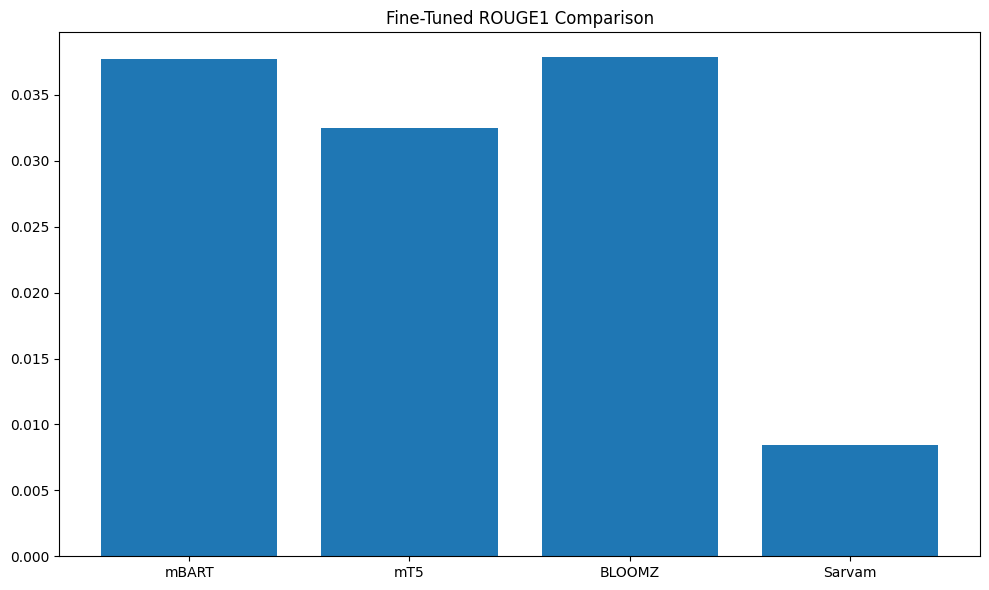

In [ ]:
plt.figure(figsize=(10,6))

plt.bar(labels, finetuned_df["ROUGE1"])

plt.title("Fine-Tuned ROUGE1 Comparison")
plt.tight_layout()

plt.savefig(f"{BASE_DIR}/finetuned_rouge1_comparison.png")
plt.show()

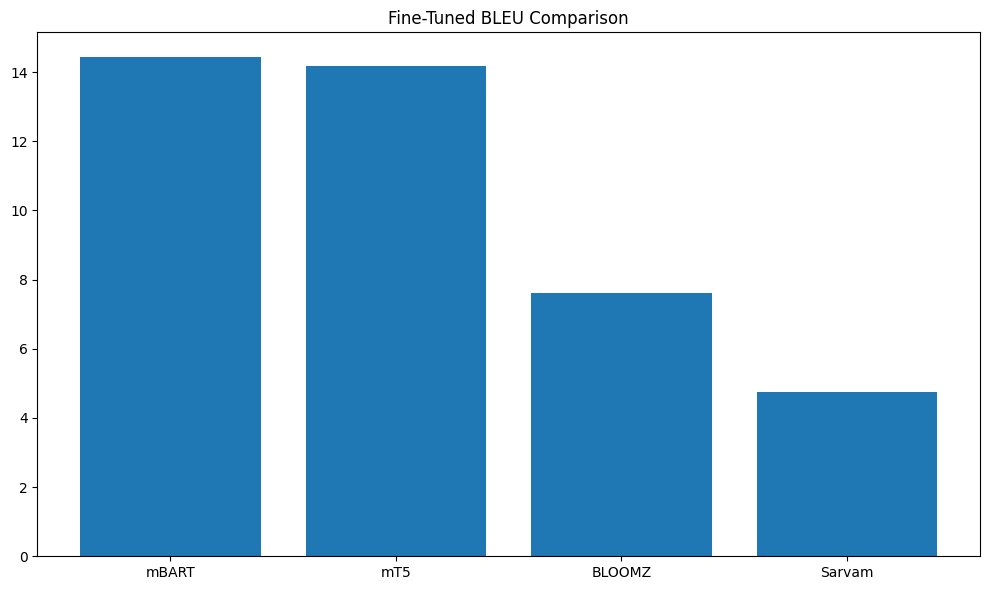

In [ ]:
plt.figure(figsize=(10,6))

plt.bar(labels, finetuned_df["BLEU"])

plt.title("Fine-Tuned BLEU Comparison")
plt.tight_layout()

plt.savefig(f"{BASE_DIR}/finetuned_bleu_comparison.png")
plt.show()

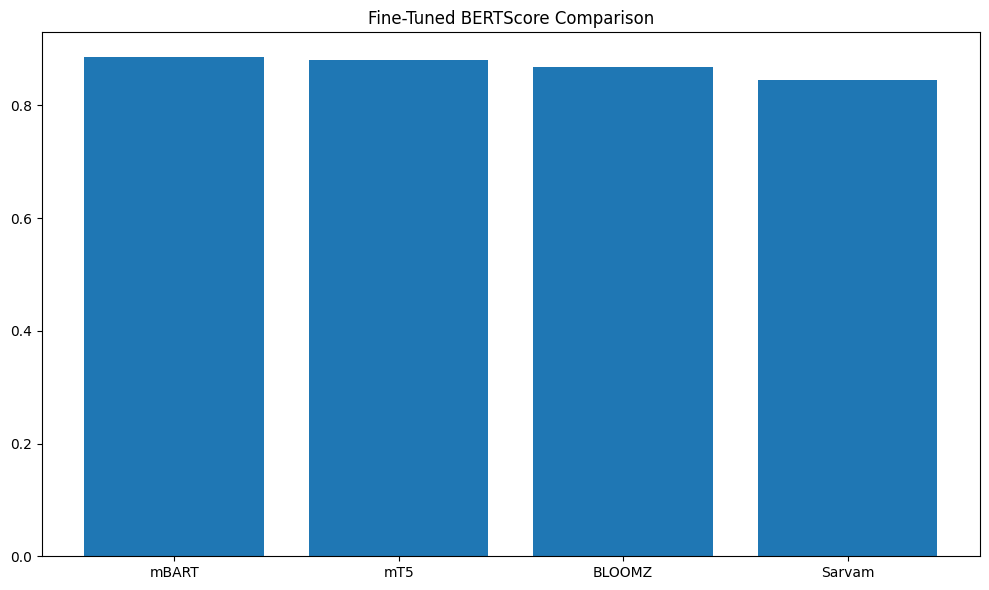

In [ ]:
plt.figure(figsize=(10,6))

plt.bar(labels, finetuned_df["BERTScore"])

plt.title("Fine-Tuned BERTScore Comparison")
plt.tight_layout()

plt.savefig(f"{BASE_DIR}/finetuned_bertscore_comparison.png")
plt.show()

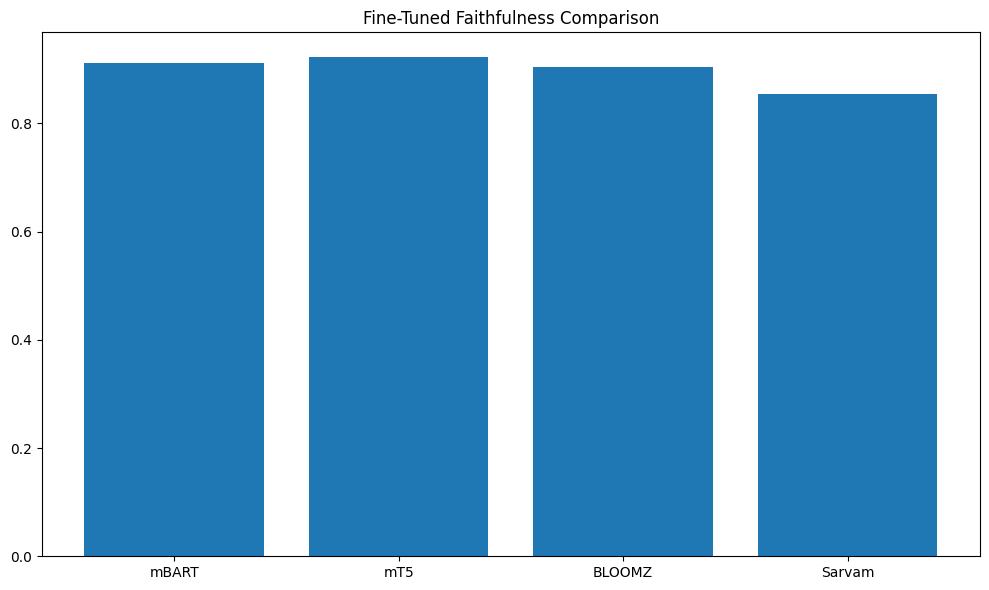

In [ ]:
plt.figure(figsize=(10,6))

plt.bar(labels, finetuned_df["Faithfulness"])

plt.title("Fine-Tuned Faithfulness Comparison")
plt.tight_layout()

plt.savefig(f"{BASE_DIR}/finetuned_faithfulness_comparison.png")
plt.show()

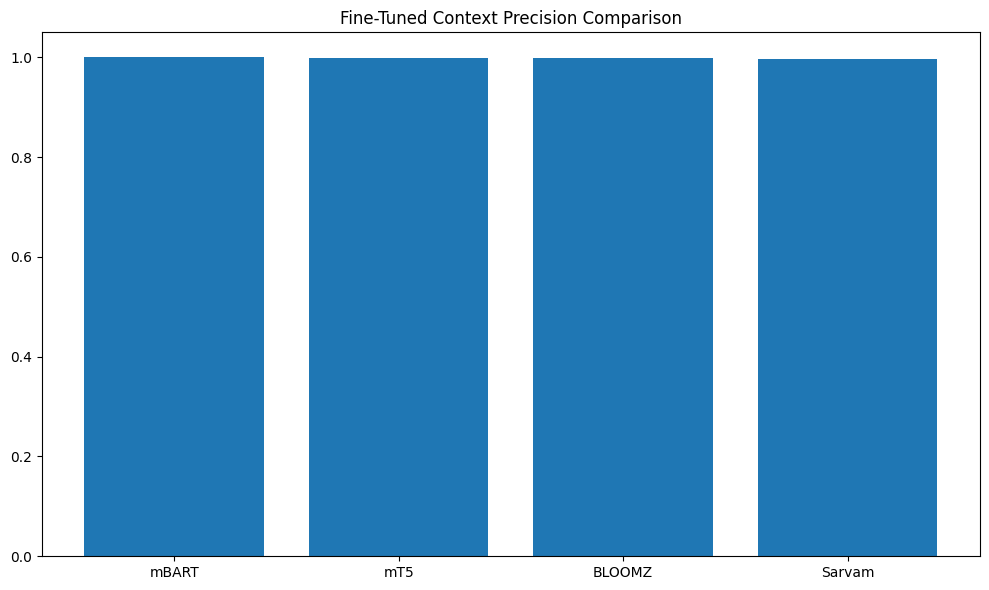

In [ ]:
plt.figure(figsize=(10,6))

plt.bar(labels, finetuned_df["ContextPrecision"])

plt.title("Fine-Tuned Context Precision Comparison")
plt.tight_layout()

plt.savefig(f"{BASE_DIR}/finetuned_context_precision_comparison.png")
plt.show()

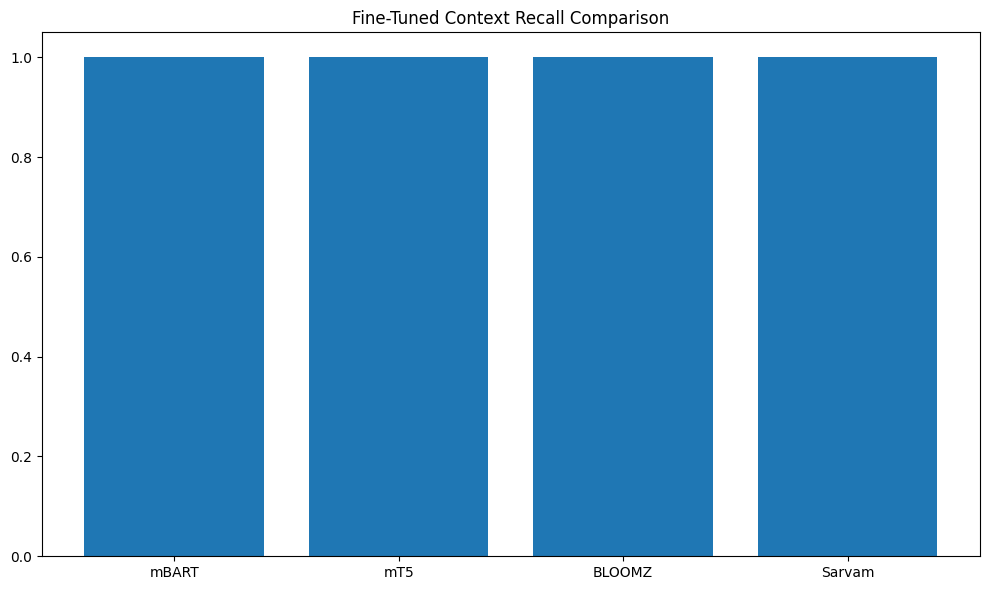

In [ ]:
plt.figure(figsize=(10,6))

plt.bar(labels, finetuned_df["ContextRecall"])

plt.title("Fine-Tuned Context Recall Comparison")
plt.tight_layout()

plt.savefig(f"{BASE_DIR}/finetuned_context_recall_comparison.png")
plt.show()

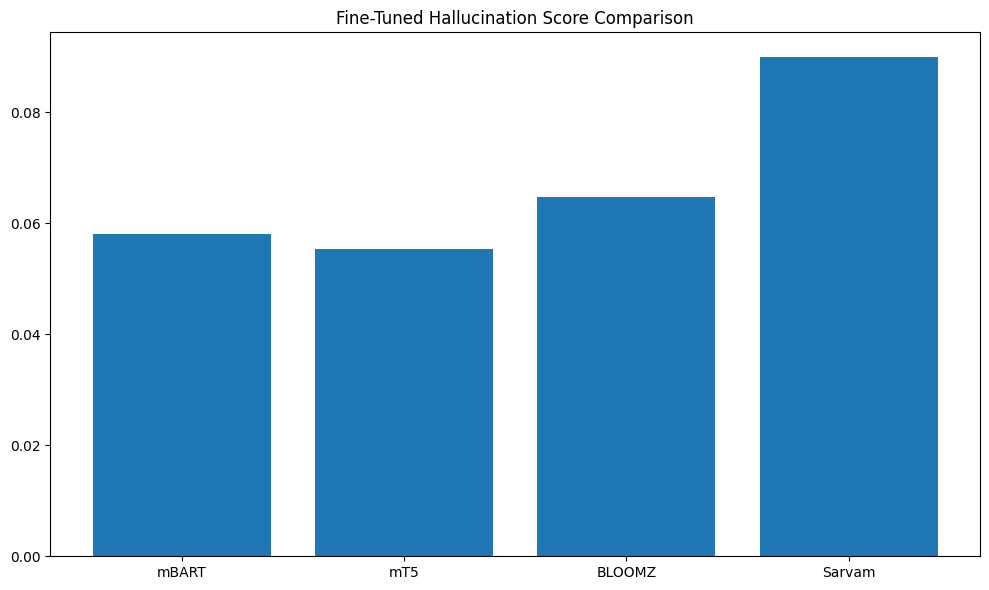

In [ ]:
plt.figure(figsize=(10,6))

plt.bar(labels, finetuned_df["HallucinationScore"])

plt.title("Fine-Tuned Hallucination Score Comparison")
plt.tight_layout()

plt.savefig(f"{BASE_DIR}/finetuned_hallucination_comparison.png")
plt.show()

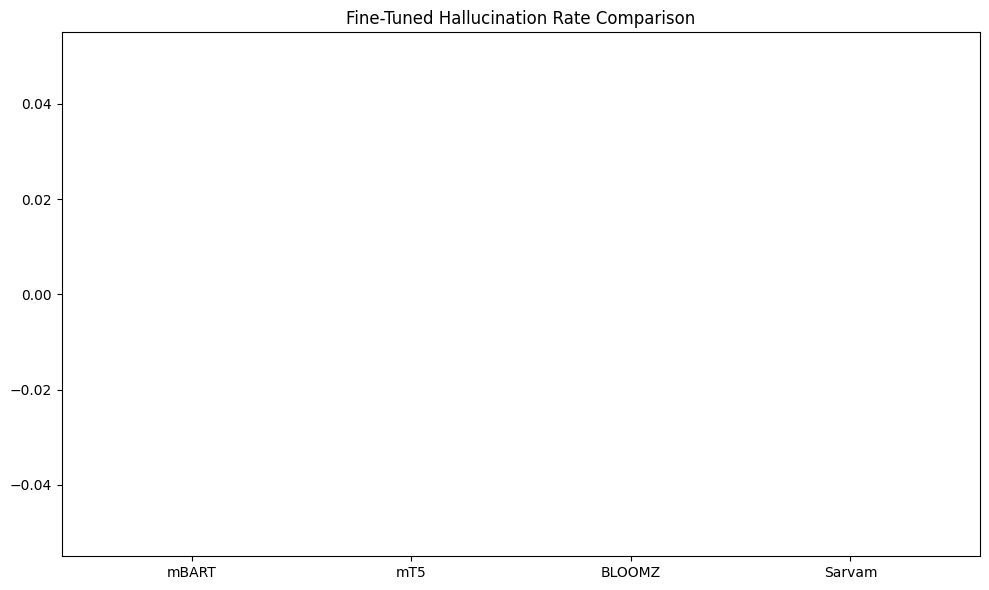

In [ ]:
plt.figure(figsize=(10,6))

plt.bar(labels, finetuned_df["HallucinationRate"])

plt.title("Fine-Tuned Hallucination Rate Comparison")
plt.tight_layout()

plt.savefig(f"{BASE_DIR}/finetuned_hallucination_rate_comparison.png")
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

BASE_DIR = "/content/drive/MyDrive/MALAYALAM_FINETUNED_EVALUATION"

zero_df = pd.read_csv(f"{BASE_DIR}/zero_shot_summary.csv")
two_df = pd.read_csv(f"{BASE_DIR}/two_shot_summary.csv")
finetuned_df = pd.read_csv(f"{BASE_DIR}/finetuned_summary.csv")

master_df = pd.concat(
    [zero_df, two_df, finetuned_df],
    ignore_index=True
)

display(master_df)

,Model,Setting,ROUGE1,ROUGE2,ROUGEL,BLEU,BERTScore,Faithfulness,ContextPrecision,ContextRecall,HallucinationScore,HallucinationRate
0,Sarvam,ZeroShot,0.002168,0.000142,0.002208,0.802404,0.816132,0.854938,0.967010,1.0,0.101397,0.0
1,BLOOMZ,ZeroShot,0.013747,0.000000,0.013727,1.068298,0.795823,0.811640,0.992784,1.0,0.117623,0.0
2,mT5,ZeroShot,0.000295,0.000000,0.000295,0.025067,0.768236,0.763569,1.000000,1.0,0.140925,0.0
3,mBART,ZeroShot,0.014320,0.001718,0.014489,0.686449,0.809734,0.847780,0.898969,1.0,0.119147,0.0
4,Sarvam,TwoShot,0.000471,0.000000,0.000451,0.342049,0.816985,0.838780,1.000000,1.0,0.101091,0.0
5,BLOOMZ,TwoShot,0.009966,0.000000,0.009966,0.024048,0.773784,0.772429,0.991753,1.0,0.137921,0.0
6,mT5,TwoShot,0.004400,0.000395,0.004380,0.957940,0.834877,0.874746,1.000000,1.0,0.083126,0.0
7,mBART,TwoShot,0.006529,0.000000,0.006186,1.524800,0.802297,0.818707,0.824742,1.0,0.147110,0.0
8,mBART,FineTuned,0.037698,0.001718,0.037457,14.426935,0.885237,0.912175,1.000000,1.0,0.058083,0.0
9,mT5,FineTuned,0.032509,0.001031,0.032887,14.176625,0.879882,0.922249,0.998969,1.0,0.055330,0.0


In [ ]:
master_df.to_csv(
    f"{BASE_DIR}/master_12_model_comparison.csv",
    index=False
)

print("saved")

saved


In [ ]:
best_quality = master_df.sort_values(
    by="ROUGE1",
    ascending=False
)

display(best_quality)

best_quality.to_csv(
    f"{BASE_DIR}/ranked_by_rouge1.csv",
    index=False
)

,Model,Setting,ROUGE1,ROUGE2,ROUGEL,BLEU,BERTScore,Faithfulness,ContextPrecision,ContextRecall,HallucinationScore,HallucinationRate
10,BLOOMZ,FineTuned,0.037849,0.003918,0.037996,7.623247,0.868031,0.904513,0.998969,1.0,0.064795,0.0
8,mBART,FineTuned,0.037698,0.001718,0.037457,14.426935,0.885237,0.912175,1.000000,1.0,0.058083,0.0
9,mT5,FineTuned,0.032509,0.001031,0.032887,14.176625,0.879882,0.922249,0.998969,1.0,0.055330,0.0
3,mBART,ZeroShot,0.014320,0.001718,0.014489,0.686449,0.809734,0.847780,0.898969,1.0,0.119147,0.0
1,BLOOMZ,ZeroShot,0.013747,0.000000,0.013727,1.068298,0.795823,0.811640,0.992784,1.0,0.117623,0.0
5,BLOOMZ,TwoShot,0.009966,0.000000,0.009966,0.024048,0.773784,0.772429,0.991753,1.0,0.137921,0.0
11,Sarvam,FineTuned,0.008460,0.000187,0.008423,4.756983,0.845490,0.854639,0.995876,1.0,0.089871,0.0
7,mBART,TwoShot,0.006529,0.000000,0.006186,1.524800,0.802297,0.818707,0.824742,1.0,0.147110,0.0
6,mT5,TwoShot,0.004400,0.000395,0.004380,0.957940,0.834877,0.874746,1.000000,1.0,0.083126,0.0
0,Sarvam,ZeroShot,0.002168,0.000142,0.002208,0.802404,0.816132,0.854938,0.967010,1.0,0.101397,0.0


In [ ]:
best_hallu = master_df.sort_values(
    by="HallucinationScore",
    ascending=True
)

display(best_hallu)

best_hallu.to_csv(
    f"{BASE_DIR}/ranked_by_hallucination.csv",
    index=False
)

,Model,Setting,ROUGE1,ROUGE2,ROUGEL,BLEU,BERTScore,Faithfulness,ContextPrecision,ContextRecall,HallucinationScore,HallucinationRate
9,mT5,FineTuned,0.032509,0.001031,0.032887,14.176625,0.879882,0.922249,0.998969,1.0,0.055330,0.0
8,mBART,FineTuned,0.037698,0.001718,0.037457,14.426935,0.885237,0.912175,1.000000,1.0,0.058083,0.0
10,BLOOMZ,FineTuned,0.037849,0.003918,0.037996,7.623247,0.868031,0.904513,0.998969,1.0,0.064795,0.0
6,mT5,TwoShot,0.004400,0.000395,0.004380,0.957940,0.834877,0.874746,1.000000,1.0,0.083126,0.0
11,Sarvam,FineTuned,0.008460,0.000187,0.008423,4.756983,0.845490,0.854639,0.995876,1.0,0.089871,0.0
4,Sarvam,TwoShot,0.000471,0.000000,0.000451,0.342049,0.816985,0.838780,1.000000,1.0,0.101091,0.0
0,Sarvam,ZeroShot,0.002168,0.000142,0.002208,0.802404,0.816132,0.854938,0.967010,1.0,0.101397,0.0
1,BLOOMZ,ZeroShot,0.013747,0.000000,0.013727,1.068298,0.795823,0.811640,0.992784,1.0,0.117623,0.0
3,mBART,ZeroShot,0.014320,0.001718,0.014489,0.686449,0.809734,0.847780,0.898969,1.0,0.119147,0.0
5,BLOOMZ,TwoShot,0.009966,0.000000,0.009966,0.024048,0.773784,0.772429,0.991753,1.0,0.137921,0.0


In [ ]:
labels = master_df["Model"] + "_" + master_df["Setting"]

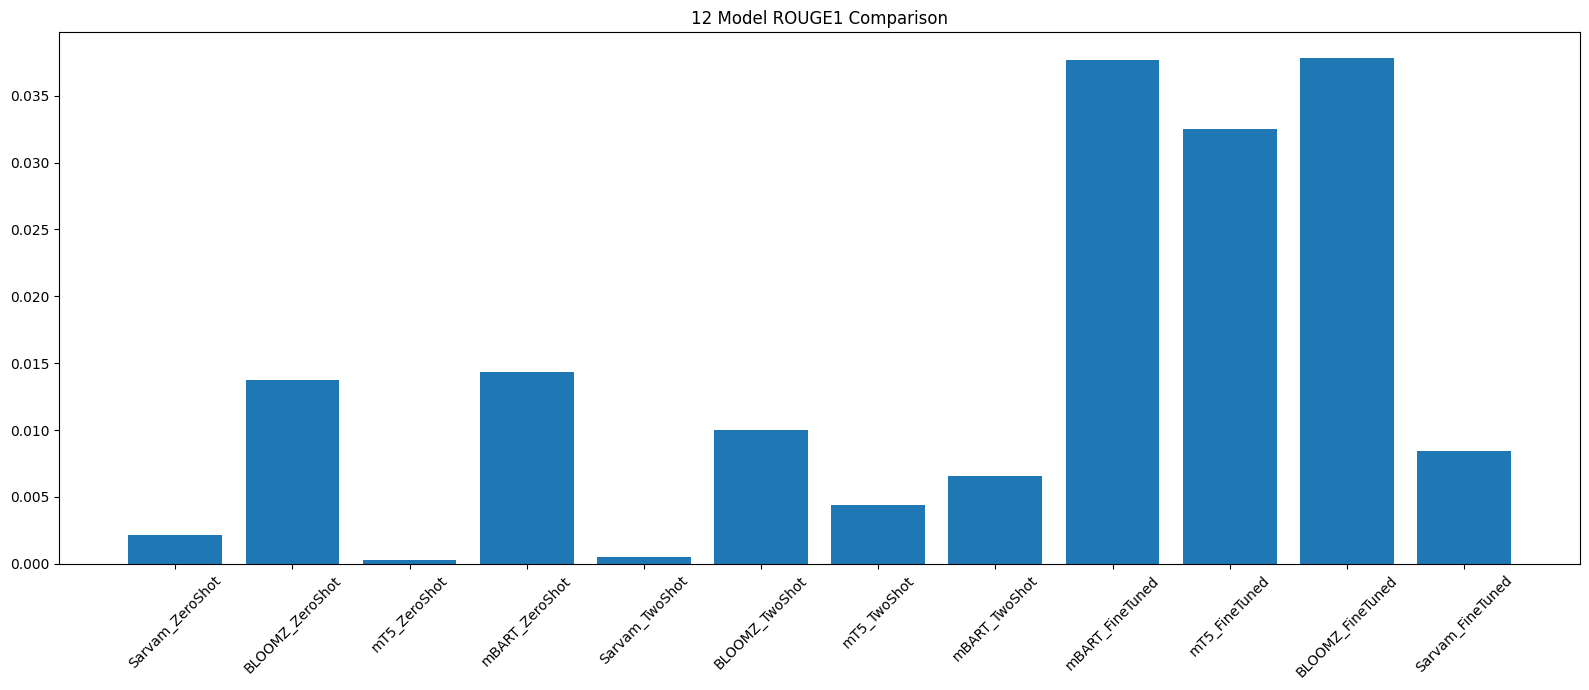

In [ ]:
plt.figure(figsize=(16,7))

plt.bar(labels, master_df["ROUGE1"])

plt.xticks(rotation=45)
plt.title("12 Model ROUGE1 Comparison")
plt.tight_layout()

plt.savefig(f"{BASE_DIR}/master_rouge1_comparison.png")
plt.show()

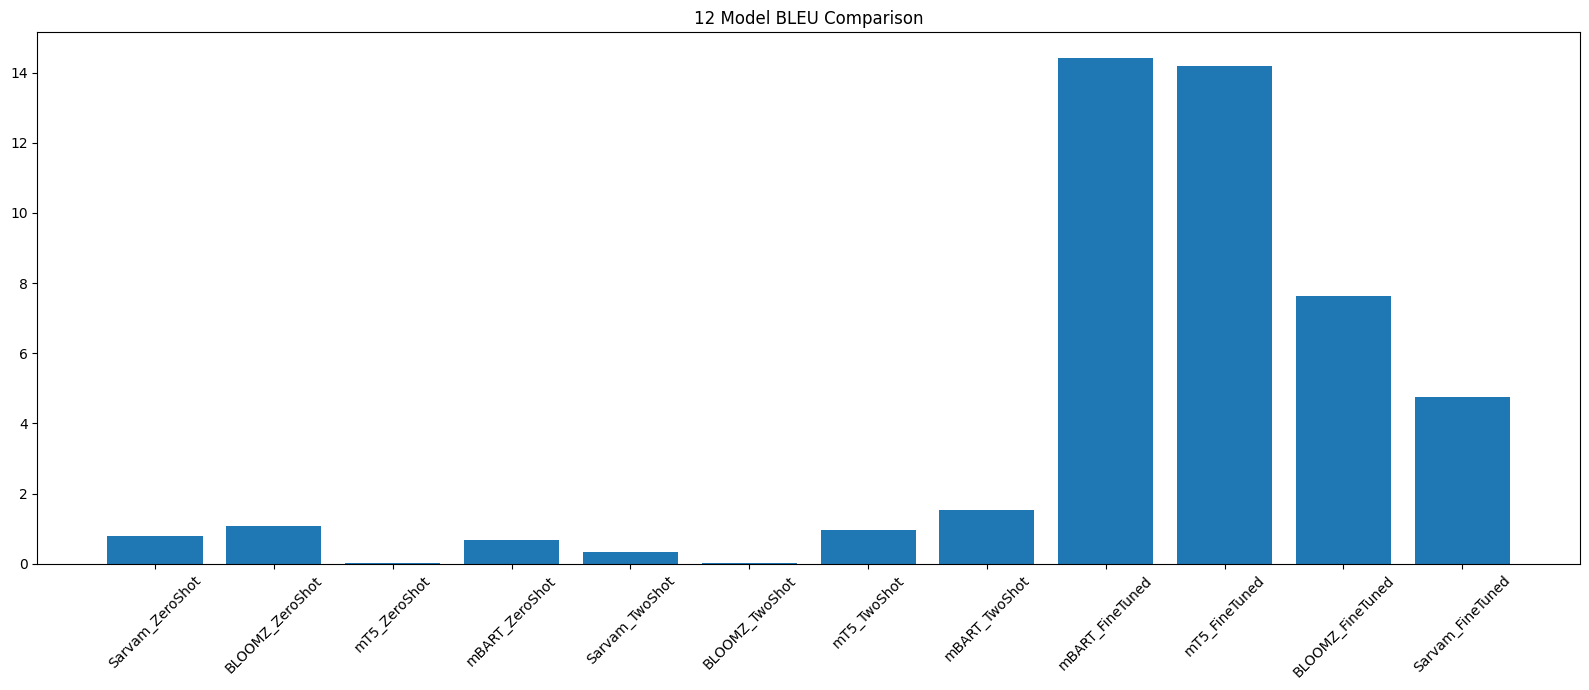

In [ ]:
plt.figure(figsize=(16,7))

plt.bar(labels, master_df["BLEU"])

plt.xticks(rotation=45)
plt.title("12 Model BLEU Comparison")
plt.tight_layout()

plt.savefig(f"{BASE_DIR}/master_bleu_comparison.png")
plt.show()

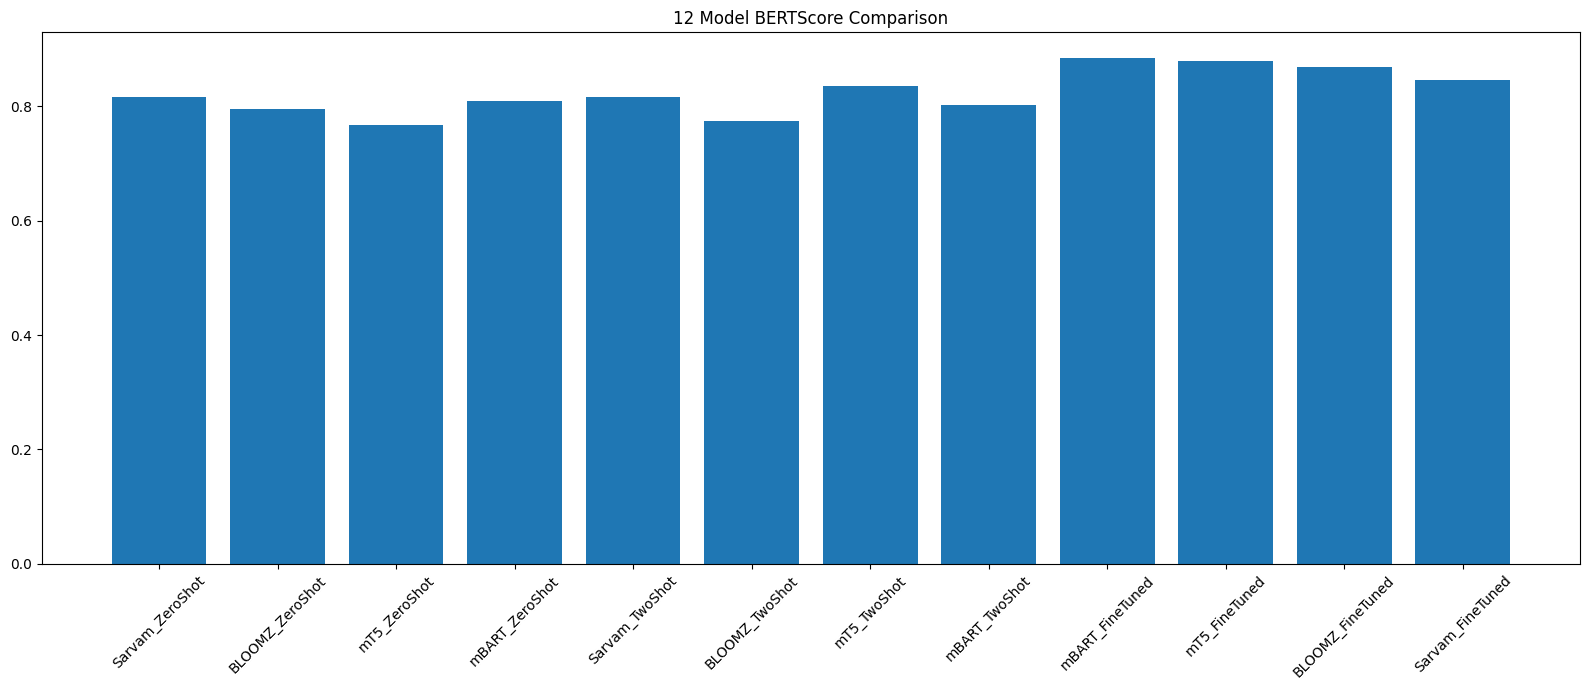

In [ ]:
plt.figure(figsize=(16,7))

plt.bar(labels, master_df["BERTScore"])

plt.xticks(rotation=45)
plt.title("12 Model BERTScore Comparison")
plt.tight_layout()

plt.savefig(f"{BASE_DIR}/master_bertscore_comparison.png")
plt.show()

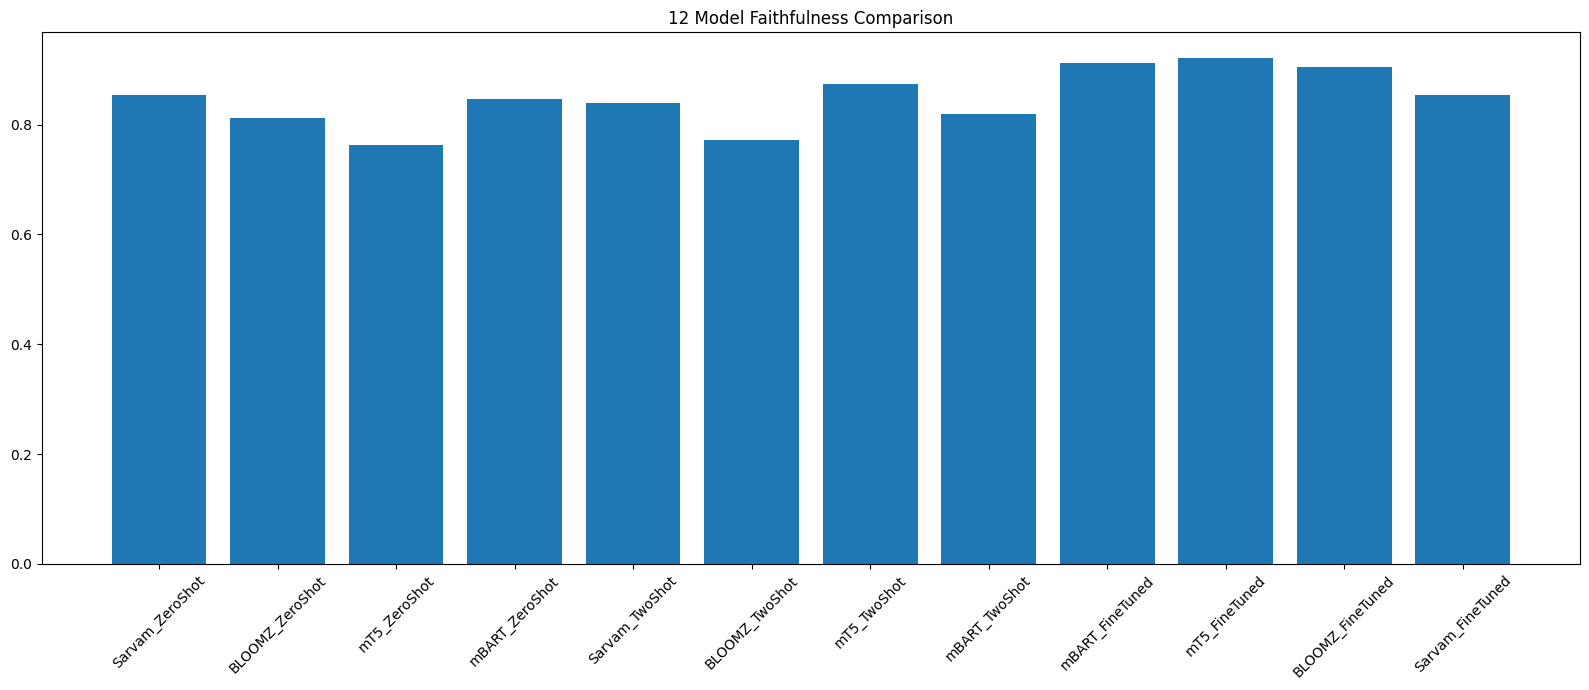

In [ ]:
plt.figure(figsize=(16,7))

plt.bar(labels, master_df["Faithfulness"])

plt.xticks(rotation=45)
plt.title("12 Model Faithfulness Comparison")
plt.tight_layout()

plt.savefig(f"{BASE_DIR}/master_faithfulness_comparison.png")
plt.show()

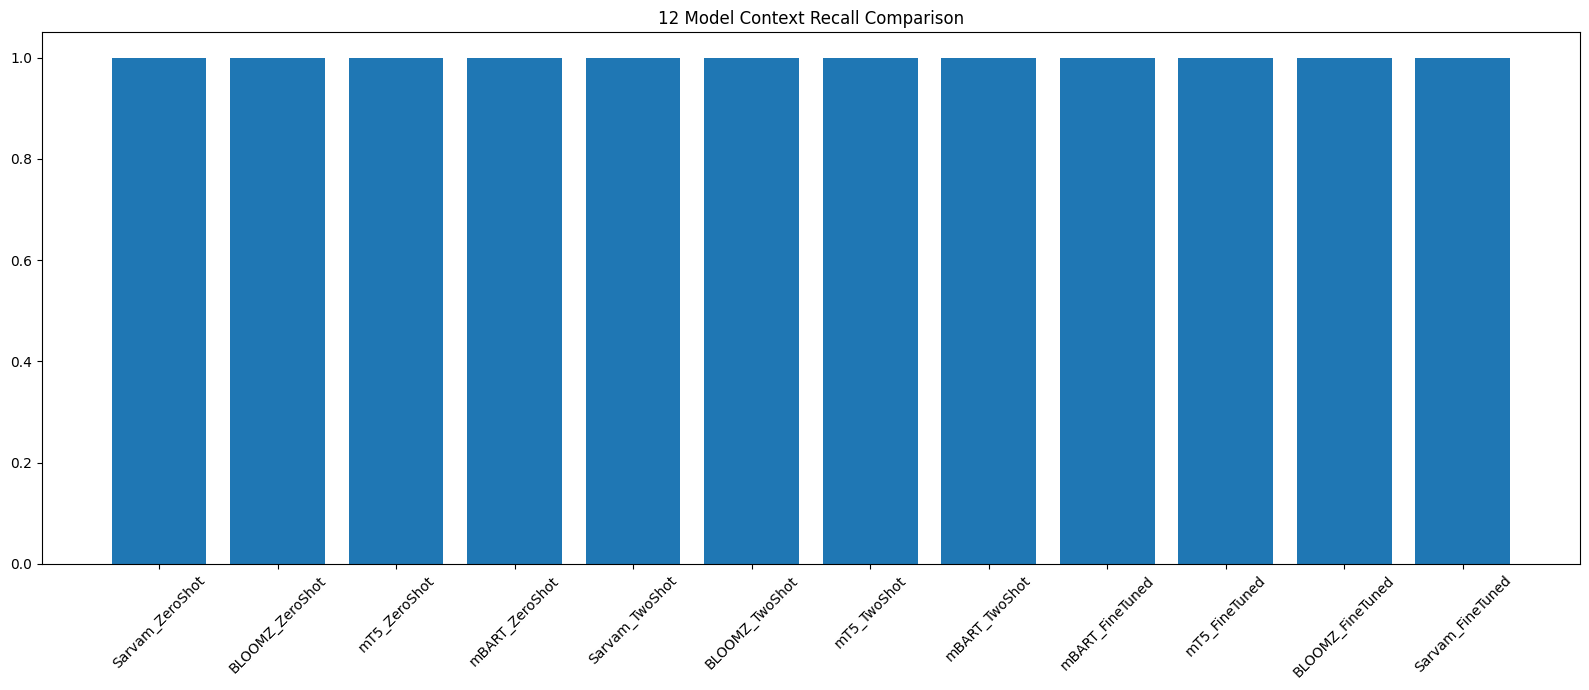

In [ ]:
plt.figure(figsize=(16,7))

plt.bar(labels, master_df["ContextRecall"])

plt.xticks(rotation=45)
plt.title("12 Model Context Recall Comparison")
plt.tight_layout()

plt.savefig(f"{BASE_DIR}/master_context_recall_comparison.png")
plt.show()

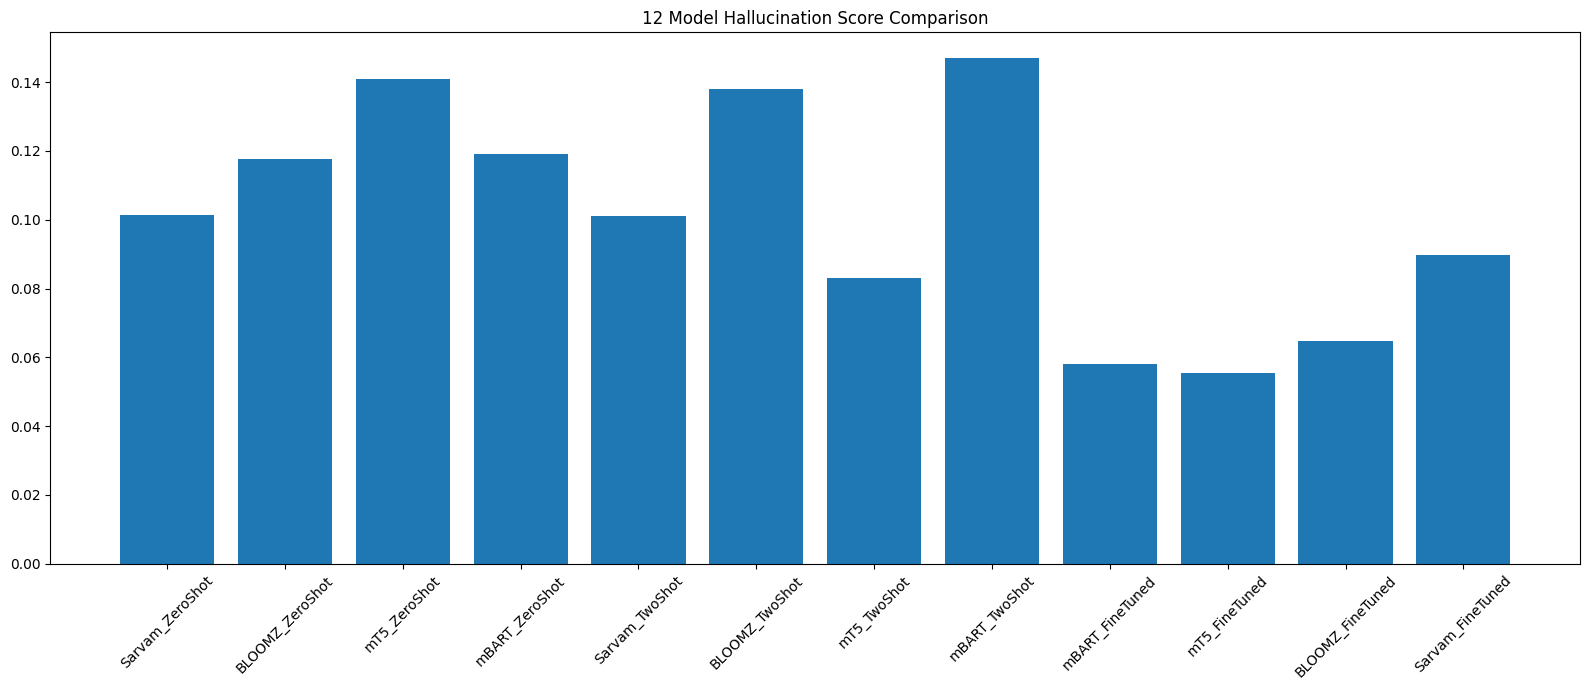

In [ ]:
plt.figure(figsize=(16,7))

plt.bar(labels, master_df["HallucinationScore"])

plt.xticks(rotation=45)
plt.title("12 Model Hallucination Score Comparison")
plt.tight_layout()

plt.savefig(f"{BASE_DIR}/master_hallucination_comparison.png")
plt.show()